# 变分分类器

本教程展示如何使用 DeepQuantum 实现变分量子分类器——这种量子线路可以通过有标签数据的训练来对新的数据样本进行分类[1][2]。

我们将展示一个示例，如何优化变分线路以模拟奇偶校验函数：

$$\begin{aligned}
f: x \in \{0,1\}^{\otimes n} \rightarrow y =
\begin{cases} 1 \text{  如果 } x \text{ 中1的数量是奇数} \\ 0
\text{  否则}. \end{cases}
\end{aligned}$$

这将展示如何将二进制输入编码到变分电路的初始状态中，这一状态仅仅是一个计算基态（*基础编码*）。

拟合奇偶校验函数
==============================

### 数据讲解

变分分类器通常定义一个“层”或“块”，这是一个基本的线路架构，通过重复来构建完整的变分线路。

我们的线路层将使用四个量子位，由每个量子位上的任意旋转以及将每个量子位与其邻居纠缠的 CNOT 环组成。借鉴机器学习的术语，我们将层的参数称为 `weights`。

我们还需要一种方法将数据输入 $x$ 编码到线路中，使得测量输出依赖于输入。输入是比特串，我们将其编码到量子位的状态中。经过状态准备后的量子状态 $\psi$ 是一个计算基态，其1的位置与 $x$ 中的1相对应，例如：

$$x = 0101 \rightarrow |\psi \rangle = |0101 \rangle .$$

这里，我们先给出预先生成的奇偶校验函数对应的数据集，数据的前四位对应随机二进制数，后一位是其奇数偶数的标签：

In [1]:
import torch
import torch.nn as nn
import math
import deepquantum as dq
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import torch.optim as optim

train_data = [0,1,0,0,1,
0, 1, 0, 1, 0,
0, 1, 1, 0, 0,
0, 1, 1, 1, 1,
1, 0, 0, 0, 1,
1, 0, 0, 1, 0,
1, 0, 1, 0, 0,
1, 0, 1, 1, 1,
1, 1, 0, 0, 0,
1, 1, 0, 1, 1,
1, 1, 1, 0, 1,
1, 1, 1, 1, 0]


test_data= [0, 0, 0, 0, 0,
0, 0, 0, 1, 1,
0, 0, 1, 0, 1,
0, 0, 1, 1, 0]

def get_train_data():
    datasets = np.array(train_data)

    datasets = datasets.reshape([-1,5])
    data = datasets[:,:-1]
    label = datasets[:,-1].astype(int)
    label = np.eye(2)[label].reshape(-1,2)

    # 将 NumPy 数组转换为 PyTorch 张量
    data = torch.tensor(data)
    label = torch.tensor(label)
    return data, label

def get_test_data():
    datasets = np.array(test_data)

    datasets = datasets.reshape([-1,5])
    data = datasets[:,:-1]
    label = datasets[:,-1].astype(int)
    label = np.eye(2)[label].reshape(-1,2)

    # 将 NumPy 数组转换为 PyTorch 张量
    data = torch.tensor(data)
    label = torch.tensor(label)
    return data, label

### 线路结构

现在我们定义变分量子线路，它由这种状态准备结构和层结构的重复组成。

如果我们想加入一个“经典”的偏置参数，可以用状态准备结构完成。

In [2]:
## 定义VQC模块
class Qcircuit(nn.Module):
    def __init__(self, input_size):
        super(Qcircuit, self).__init__()
        n_qubits = input_size  #定义比特个数
        self.cir = dq.QubitCircuit(n_qubits, reupload=True)

        self.cir.rylayer(encode=True)  #状态准备结构

        self.cir.barrier()
        self.cir.cnot_ring()
        self.cir.barrier()
        self.cir.cnot_ring(step=2)
        self.cir.barrier()
        self.cir.u3layer()

        self.cir.barrier()     #两层变分线路模块
        self.cir.cnot_ring()
        self.cir.barrier()
        self.cir.cnot_ring(step=2)
        self.cir.barrier()
        self.cir.u3layer()

        self.cir.barrier()     #三层变分线路模块
        self.cir.cnot_ring()
        self.cir.barrier()
        self.cir.cnot_ring(step=2)
        self.cir.barrier()
        self.cir.u3layer()

        self.cir.measure(wires=0)
        
        self.cir.observable(wires=0, basis='z')

    def forward(self, x):

        ry_parameter = x*np.pi  
        self.cir(ry_parameter)  

        prob=self.cir.expectation()*self.cir.expectation()
        
        return torch.cat([1-prob,prob], dim=1)

我们画出4比特量子线路，输入[0,1,0,1]，可以看见状态准备结构在对应的量子线路上加了Ry门，以实现经典信息的编码。

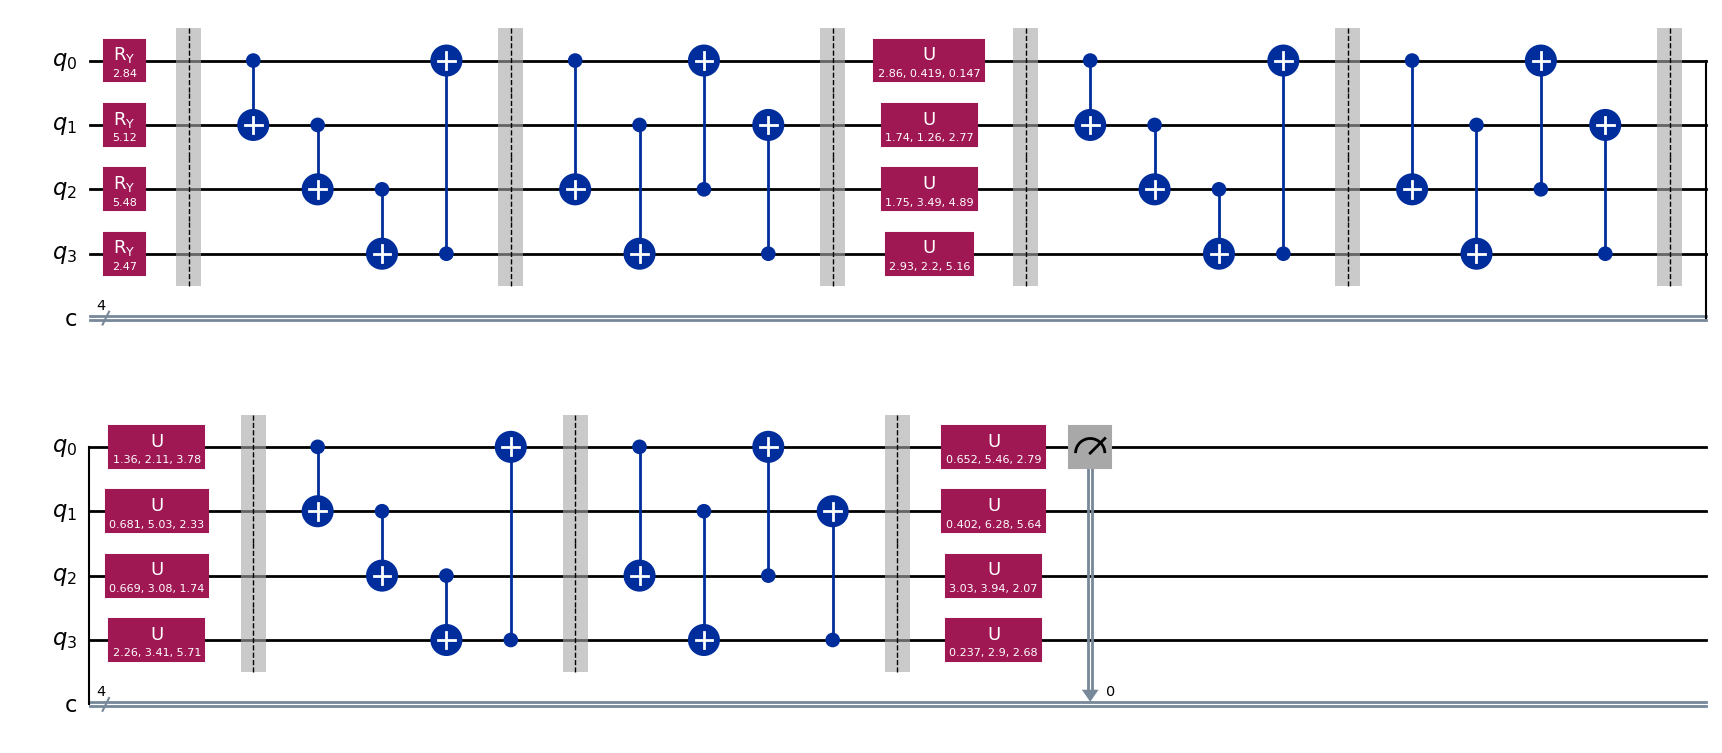

In [3]:
model=Qcircuit(4)
model.cir.draw()

# 训练优化

我们先写出计算准确率的函数：

In [4]:
# 计算准确率
def calculate_score(y_true, y_preds):
    # 将模型预测结果转为概率分布
    preds_prob = torch.softmax(y_preds, dim=1)
    # 获得预测的类别（概率最高的一类）
    preds_class = torch.argmax(preds_prob, dim=1)

    # 将模型预测结果转为概率分布
    true_prob = torch.softmax(y_true, dim=1)
    # 获得预测的类别（概率最高的一类）
    true_class = torch.argmax(true_prob, dim=1)

    # 计算准确率
    correct = (preds_class == true_class).float()
    accuracy = correct.sum() / len(correct)
    return accuracy.cpu().numpy()

# 创建 TensorDataset
train_features, train_labels=get_train_data()
test_features, test_labels=get_test_data()

train_dataset = TensorDataset(train_features, train_labels)
test_dataset = TensorDataset(test_features, test_labels)
# 创建 DataLoader
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

训练模型并进行验证集的测试：

In [5]:
def train_model(model, criterion, optimizer, train_loader, valid_loader, num_epochs, device):
    """
    训练和验证模型。

    Args:
        model (torch.nn.Module): 要训练的模型。
        criterion (torch.nn.Module): 损失函数。
        optimizer (torch.optim.Optimizer): 优化器。
        train_loader (torch.utils.data.DataLoader): 训练数据加载器。
        valid_loader (torch.utils.data.DataLoader): 验证数据加载器。
        num_epochs (int): 训练的epoch数。

    Returns:
        model (torch.nn.Module): 训练后的模型。
    """

    model.train()
    train_loss_list = []
    valid_loss_list = []
    train_acc_list = []
    valid_acc_list = []
    for epoch in tqdm(range(num_epochs)):
        # 训练阶段
        train_loss = 0.0
        train_acc = 0.0
        for data, labels in train_loader:
            data = data.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(data)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_acc += calculate_score(labels, outputs)
        train_loss /= len(train_loader)
        train_acc /= len(train_loader)

        # 验证阶段
        model.eval()
        valid_loss = 0.0
        valid_acc = 0.0
        with torch.no_grad():
            for data, labels in valid_loader:
                data = data.to(device)
                labels = labels.to(device)
                outputs = model(data)
                loss = criterion(outputs, labels)
                valid_loss += loss.item()
                valid_acc += calculate_score(labels, outputs)
        valid_loss /= len(valid_loader)
        valid_acc /= len(valid_loader)

        print(f'Train Loss: {train_loss:.3f} Train Acc: {train_acc:.3f} '
              f'Valid Loss: {valid_loss:.3f} Valid Acc: {valid_acc:.3f}')
        train_loss_list.append(train_loss)
        valid_loss_list.append(valid_loss)
        train_acc_list.append(train_acc)
        valid_acc_list.append(valid_acc)
    metrics = {'epoch': list(range(1, num_epochs + 1)),
                'train_acc': train_acc_list,
                'valid_acc': valid_acc_list,
                'train_loss': train_loss_list,
                'valid_loss': valid_loss_list}
    return model, metrics

In [6]:
num_epochs = 20 # 训练轮数为20
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Qcircuit(4)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
optim_model, metrics = train_model(model, criterion, optimizer, train_loader, test_loader, num_epochs, device)

  5%|▌         | 1/20 [00:00<00:13,  1.40it/s]

Train Loss: 0.798 Train Acc: 0.500 Valid Loss: 0.803 Valid Acc: 0.500


 10%|█         | 2/20 [00:00<00:07,  2.37it/s]

Train Loss: 0.792 Train Acc: 0.500 Valid Loss: 0.802 Valid Acc: 0.500


 15%|█▌        | 3/20 [00:01<00:05,  3.01it/s]

...

Train Loss: 0.401 Train Acc: 1.000 Valid Loss: 0.412 Valid Acc: 1.000


 95%|█████████▌| 19/20 [00:04<00:00,  4.51it/s]

Train Loss: 0.363 Train Acc: 1.000 Valid Loss: 0.366 Valid Acc: 1.000


100%|██████████| 20/20 [00:04<00:00,  4.08it/s]

Train Loss: 0.340 Train Acc: 1.000 Valid Loss: 0.341 Valid Acc: 1.000


量子线路学会了完美地预测所有未见示例！

# 附录

[1] Farhi E, Neven H. Classification with quantum neural networks on near term processors[J]. arXiv preprint arXiv:1802.06002, 2018.

[2] Schuld M, Bocharov A, Svore K M, et al. Circuit-centric quantum classifiers[J]. Physical Review A, 2020, 101(3): 032308.